# E-commerce Sales Analysis & Customer Insights

## Objective
Analyze sales behavior, top products, and customer patterns to generate actionable business insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/online_retail_II.csv", sep=',', encoding='latin1')

In [3]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/11 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/11 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/11 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/11 12:50,4.95,12680.0,France


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  object 
 1   StockCode    541910 non-null  object 
 2   Description  540456 non-null  object 
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  object 
 5   Price        541910 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      541910 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
df.describe()

,Quantity,Price,Customer ID
count,541910.000000,541910.000000,406830.000000
mean,9.552234,4.611138,15287.684160
std,218.080957,96.759765,1713.603074
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## Data Cleaning

In [6]:
# Replace missing Customer IDs with "Unknown" to preserve transactions
df["Customer ID"] = df["Customer ID"].fillna("Unknown")

In [7]:
# Remove canceled transactions identified by invoices starting with "C"
df = df[~df["Invoice"].astype(str).str.startswith("C")]

In [8]:
# Create a new column to calculate total revenue per transaction
df["TotalPrice"] = df["Quantity"] * df["Price"]

C:\Users\veron\AppData\Local\Temp\ipykernel_14908\4050697859.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["TotalPrice"] = df["Quantity"] * df["Price"]


## Analysis

### Total Sales

In [9]:
df["TotalPrice"].sum()

10644578.424000002

### Sales Trend Over Time

C:\Users\veron\AppData\Local\Temp\ipykernel_14908\2283260887.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
C:\Users\veron\AppData\Local\Temp\ipykernel_14908\2283260887.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Month"] = df["InvoiceDate"].dt.to_period("M")


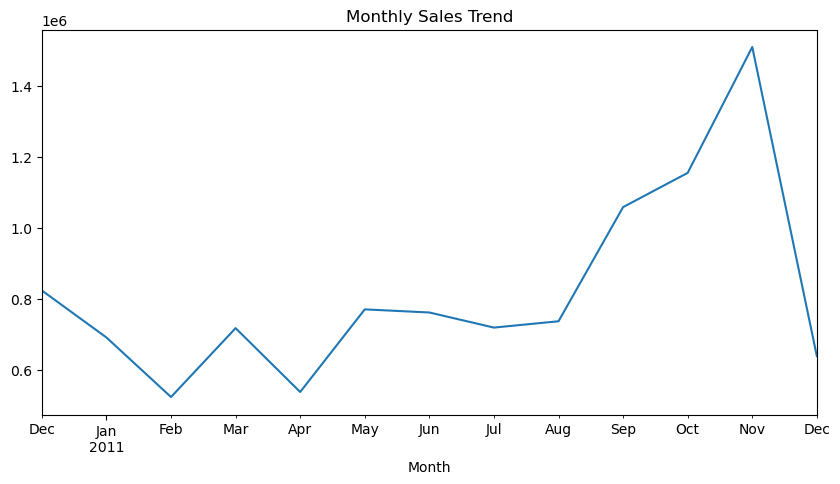

In [11]:
# Monthly Sales Trend
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Month"] = df["InvoiceDate"].dt.to_period("M")

monthly_sales = df.groupby("Month")["TotalPrice"].sum()
monthly_sales.plot(kind="line", figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.savefig("../images/Monthly Sales Trend.png", bbox_inches='tight')
plt.show()

- Sales show a significant upward trend during the last quarter of the year, 
with a sharp increase between September and November.

- November represents the peak sales month, suggesting a strong seasonal effect, 
possibly driven by holiday shopping and year-end demand.

- The sudden drop in December may indicate incomplete monthly data rather than 
an actual decrease in business performance.

- Sales performance during the first half of the year remains relatively stable, 
while the second half shows accelerated growth and stronger customer activity.

- The business appears to rely heavily on Q4 performance, which could represent 
both a revenue opportunity and a seasonal dependency risk.

### Top Products

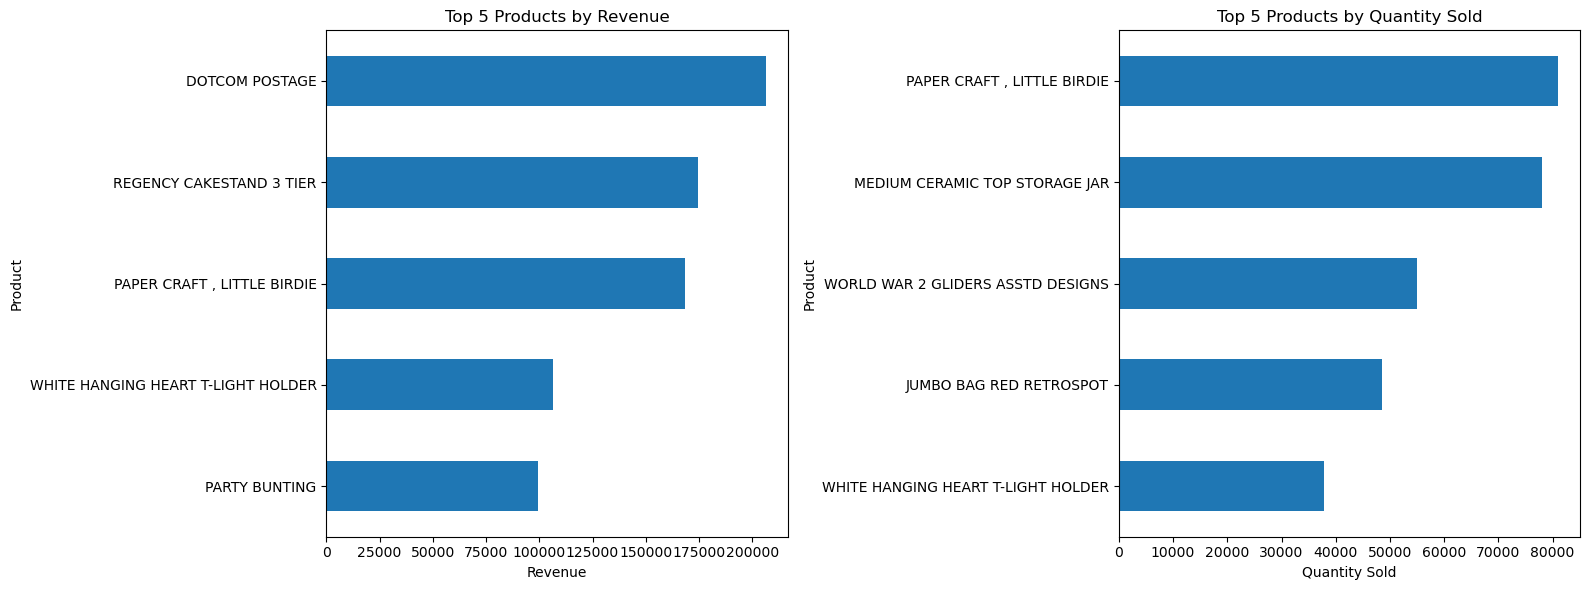

In [12]:
# Top 5 Products by Revenue & Top 5 Products by Quantity Sold
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# Top products by revenue
# -------------------------
top_revenue = (
    df.groupby("Description")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)
top_revenue.sort_values().plot(
    kind="barh",
    ax=axes[0]
)
axes[0].set_title("Top 5 Products by Revenue")
axes[0].set_xlabel("Revenue")
axes[0].set_ylabel("Product")


# Top products by quantity
# -------------------------
top_quantity = (
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)
top_quantity.sort_values().plot(
    kind="barh",
    ax=axes[1]
)
axes[1].set_title("Top 5 Products by Quantity Sold")
axes[1].set_xlabel("Quantity Sold")
axes[1].set_ylabel("Product")

plt.tight_layout()
plt.savefig("../images/top_products.png", bbox_inches='tight')
plt.show()

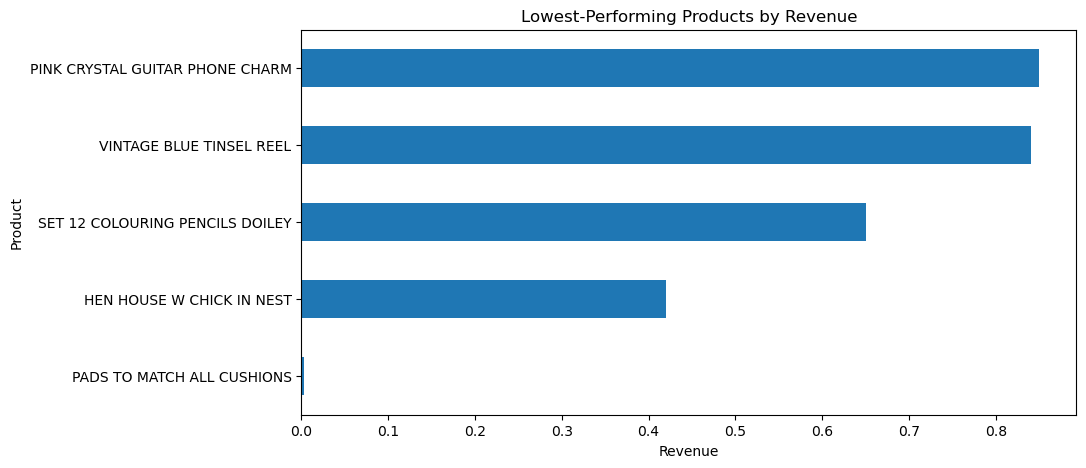

In [13]:
# Lowest-Performing Products by Revenue
product_sales = (
    df.groupby("Description")["TotalPrice"]
    .sum()
)

positive_sales = product_sales[product_sales > 0]

bottom_products = positive_sales.sort_values().head(5)

plt.figure(figsize=(10,5))
bottom_products.sort_values().plot(kind="barh")

plt.title("Lowest-Performing Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.savefig("../images/Lowest-Performing Productsn.png", bbox_inches='tight')
plt.show()

- High-revenue products are not always the most frequently purchased items. 
For example, "DOTCOM POSTAGE" generates the highest revenue despite not appearing 
among the highest-volume products, suggesting a higher average transaction value.

- Products such as "PAPER CRAFT , LITTLE BIRDIE" rank highly in both revenue and 
quantity sold, indicating strong customer demand and consistent sales performance.

- Several top-selling products by quantity generate comparatively lower revenue, 
which may indicate lower unit prices or lower profit margins.

- The presence of low-performing products with minimal revenue contribution suggests 
potential opportunities for product portfolio optimization or discontinuation strategies.

- Revenue appears to be concentrated among a relatively small subset of products, 
which could represent both a business strength and a dependency risk.

### Sales by Country

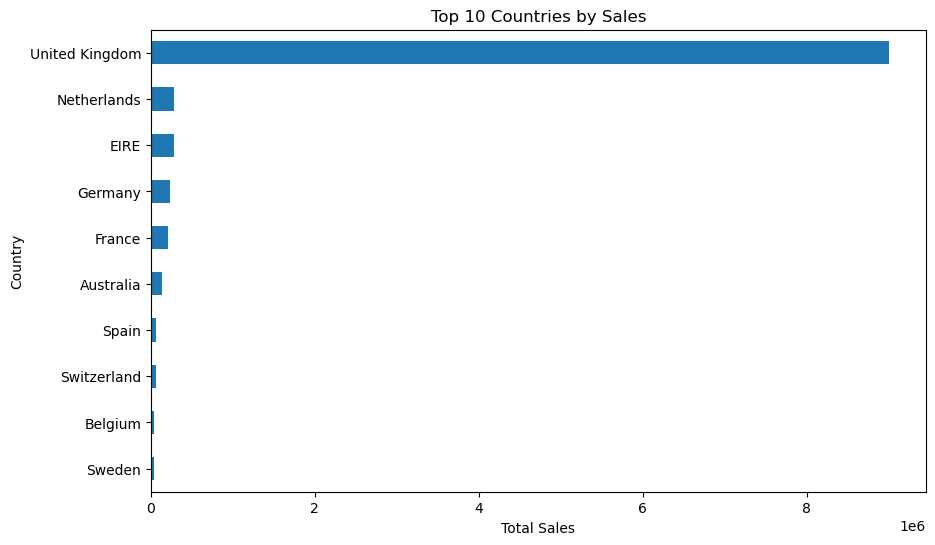

In [14]:
# Top 10 Countries by Sales
sales_country = (
    df.groupby("Country")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)

top_countries = sales_country.head(10)

plt.figure(figsize=(10,6))

top_countries.plot(kind="barh")

plt.title("Top 10 Countries by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Country")

plt.gca().invert_yaxis()

plt.savefig("../images/Top 10 Countries by Sales.png", bbox_inches='tight')
plt.show()

In [ ]:
- The United Kingdom overwhelmingly dominates total sales, contributing the vast majority of revenue compared to all other countries.

- Revenue concentration in a single market suggests strong market penetration in the UK, but also reveals a potential dependency risk on one geographic region.

- International sales outside the UK remain significantly lower, indicating potential opportunities for geographic expansion and market diversification.

- Countries such as the Netherlands, Germany, and France show moderate sales performance and could represent strategic growth markets.

- The distribution of sales across countries is highly uneven, which may impact business resilience if demand in the primary market declines.

## Customer Segmentation with RFM Analysis